<a href="https://colab.research.google.com/github/amanmeka/DataScience/blob/main/Unit6/AmanMekaU6proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 6 Project: Predicting Rookie TRB using NBA combine results


**Task**:

Two parts:

1. Propose a data set that's compatible with a generilized linear model structure built with pymc and/or bambi. Your data must have more than three potential predictor variables. I must approve your submission before you move on to part 2.

2. Create, analyze, and present a generalized linear model using pymc within the colab environment, on a data set of your choice, with the following conditions:
  - your final model must have more than 2 predictors. The intercept term doesn't count as a predictor here (even though technically it is).
  - You must document and explain your model selection method. This means you must show that your likelihood/link function combo is better than at least one other choice of likelihood/link function.
  - You must document and explain your variable selection method. This means you must show that your final model is better than at least one other version of the model with a different selection of variables.



In [2]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import graphviz as gv
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
link = "https://raw.githubusercontent.com/amanmeka/DataScience/refs/heads/main/2425rookies(pergame)%20-%201924rookfulldata%20(1).csv"
rooks = pd.read_csv(link)

In [6]:
rooks

,Rk,Player,Debut,Age,Yrs,MP,FG,FGA,3P,3PA,...,Standing Vertical,Vertical Leap,LANE,SHUTTLE,SPRINT,BENCH,BAR,PAN,PBHGT,PDHGT
0,25,Adam Flagler,Feb 23 '24 OKC vs. WAS,24,1,7.00,0.50,3.50,0.50,3.00,...,31.0,36.0,10.96,NaN,3.00,NaN,104.80%,74,128.0,133.0
1,76,Adama Sanogo,Dec 28 '23 CHI vs. IND,21,1,7.30,1.56,3.00,0.00,0.00,...,28.5,31.0,11.50,NaN,3.31,NaN,109.50%,97.5,137.0,139.5
2,3,Amari Bailey,Nov 12 '23 CHO @ NYK,19,1,6.50,0.80,2.40,0.10,0.80,...,28.5,35.0,11.00,NaN,3.19,NaN,105.00%,74,132.0,138.5
3,43,Andre Jackson Jr.,Oct 29 '23 MIL vs. ATL,22,1,10.00,0.88,1.75,0.30,0.81,...,31.0,40.0,10.83,NaN,3.00,NaN,105.50%,78.4,134.0,143.0
4,7,Anthony Black,Oct 25 '23 ORL vs. HOU,20,1,16.90,1.67,3.58,0.54,1.36,...,32.0,39.0,11.00,NaN,3.00,NaN,102.30%,78.4,134.5,141.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,63,Terance Mann,Oct 24 '19 LAC @ GSW,23,7,22.41,3.07,6.19,0.80,2.18,...,32.5,38.5,11.51,3.14,3.30,6.0,103.90%,8790.00%,133.5,139.5
186,25,Terence Davis,Oct 22 '19 TOR vs. NOP,22,5,16.09,2.90,6.69,1.45,3.96,...,29.5,34.0,10.69,2.96,3.28,13.0,107.70%,9940.00%,130.5,135.0
187,111,Tremont Waters,Nov 25 '19 BOS vs. SAC,22,3,10.18,1.30,3.68,0.53,1.78,...,30.5,40.5,10.76,3.11,3.07,5.0,106.80%,7800.00%,124.0,134.0
188,52,Ty Jerome,Dec 2 '19 PHO @ CHO,22,7,18.14,3.26,7.08,1.27,3.33,...,26.0,31.5,11.21,3.12,3.40,2.0,99.70%,7840.00%,124.0,129.5


In [ ]:
sns.pairplot(rooks)

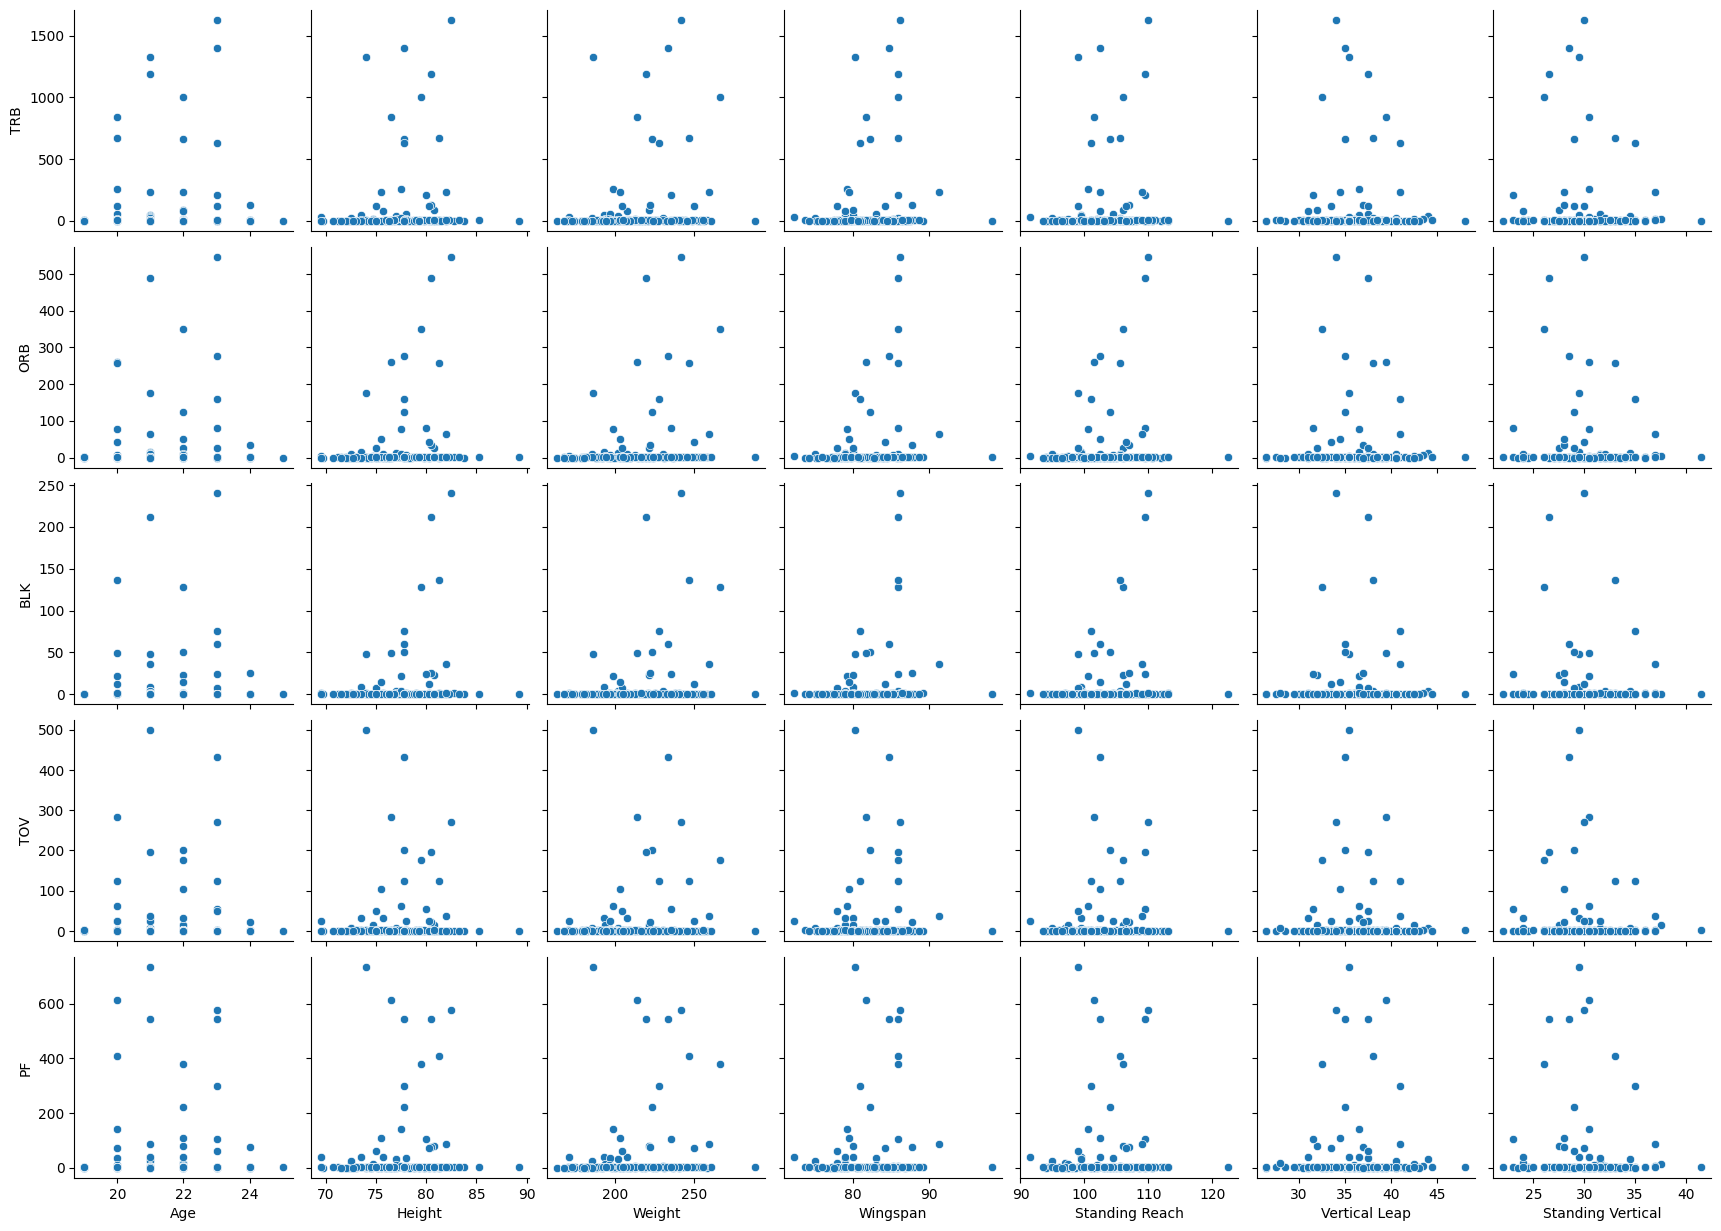

In [11]:
# Plot all other numeric variables against defensive vals
sns.pairplot(rooks, y_vars=['TRB', 'ORB', 'BLK', 'TOV', 'PF'], x_vars=['Age','Height','Weight','Wingspan','Standing Reach','Vertical Leap','Standing Vertical',])
plt.show()


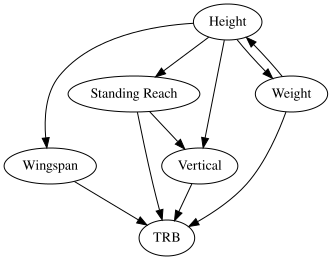

In [ ]:
#multiple predictor causal diagram
dag_b = gv.Digraph() #b for bikes

dag_b.node('A', 'Height')
dag_b.node('B', 'Wingspan')
dag_b.node('C', 'Standing Reach')
dag_b.node('D', 'TRB')
dag_b.node('E', 'Weight')
dag_b.node('F', 'Vertical')


dag_b.edges(['AB','AC', 'BD', 'CD', 'ED', 'AF', 'CF', 'FD', 'AE', 'EA'])

dag_b

In [12]:
!pip install bambi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 13.3 MB/s eta 0:00:00


In [14]:
import bambi as bmb

In [17]:
model_hsr_w = bmb.Model("'TRB' ~ 'Height':'Standing Reach' + 'Weight'" , rooks, family="gaussian")
#this is bambi's equivalent of pm.sample()
idata_model_hsr_w = model_hsr_w.fit(idata_kwargs={"log_likelihood":True})

Output()

<Axes: xlabel='TRB'>

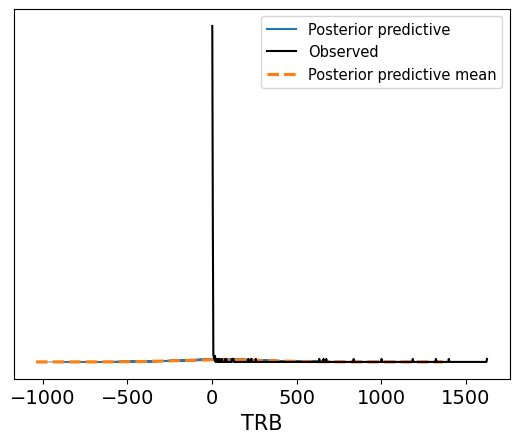

In [18]:
model_hsr_w.predict(idata_model_hsr_w, kind="response")
az.plot_ppc(idata_model_hsr_w)

In [19]:
model_h_w_sr = bmb.Model("'TRB' ~ 'Height' + 'Weight' + 'Standing Reach'" , rooks, family="gaussian")
#this is bambi's equivalent of pm.sample()
idata_model_h_w_sr = model_h_w_sr.fit(idata_kwargs={"log_likelihood":True})

Output()

<Axes: xlabel='TRB'>

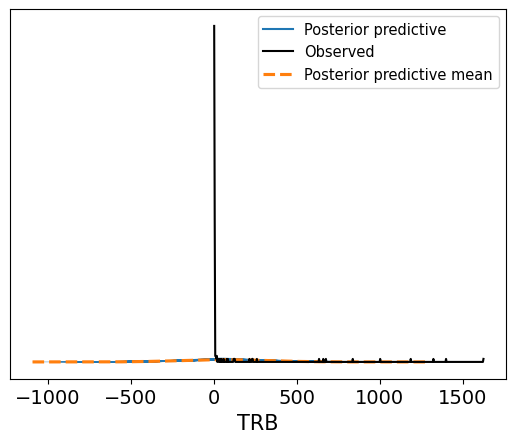

In [20]:
model_h_w_sr.predict(idata_model_h_w_sr, kind="response")
az.plot_ppc(idata_model_h_w_sr)

In [21]:
model_h = bmb.Model("'TRB' ~ 'Height'" , rooks, family="gaussian")
#this is bambi's equivalent of pm.sample()
idata_model_h = model_h.fit(idata_kwargs={"log_likelihood":True})

Output()

<Axes: xlabel='TRB'>

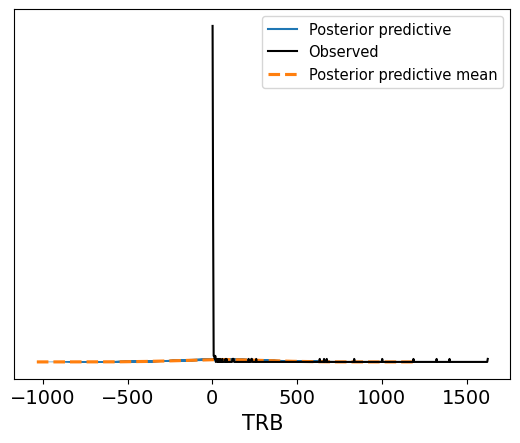

In [22]:
model_h.predict(idata_model_h, kind="response")
az.plot_ppc(idata_model_h)

In [23]:
model_w = bmb.Model("'TRB' ~ 'Weight'" , rooks, family="gaussian")
#this is bambi's equivalent of pm.sample()
idata_model_w = model_w.fit(idata_kwargs={"log_likelihood":True})

Output()

<Axes: xlabel='TRB'>

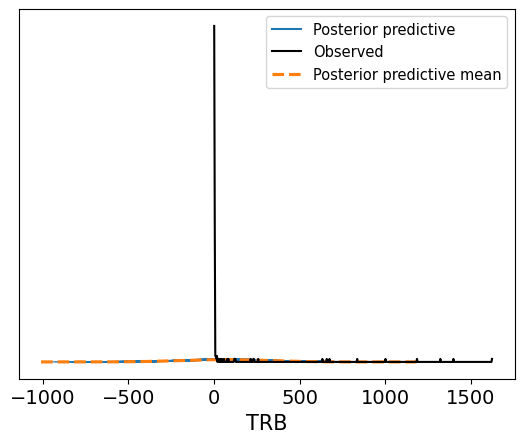

In [24]:
model_w.predict(idata_model_w, kind="response")
az.plot_ppc(idata_model_w)

In [25]:
model_hsr = bmb.Model("'TRB' ~ 'Height':'Standing Reach'" , rooks, family="gaussian")
#this is bambi's equivalent of pm.sample()
idata_model_hsr = model_hsr.fit(idata_kwargs={"log_likelihood":True})

Output()

<Axes: xlabel='TRB'>

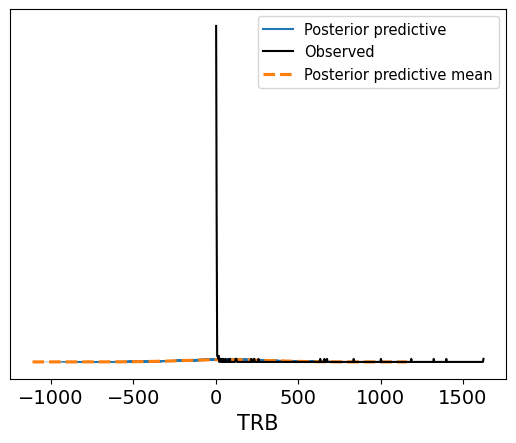

In [26]:
model_hsr.predict(idata_model_hsr, kind="response")
az.plot_ppc(idata_model_hsr)

In [27]:
model_hsr_v = bmb.Model("'TRB' ~ 'Height':'Standing Reach' + 'Standing Vertical'" , rooks, family="gaussian")
#this is bambi's equivalent Qof pm.sample()
idata_model_hsr_v = model_hsr_v.fit(idata_kwargs={"log_likelihood":True})

Output()

<Axes: xlabel='TRB'>

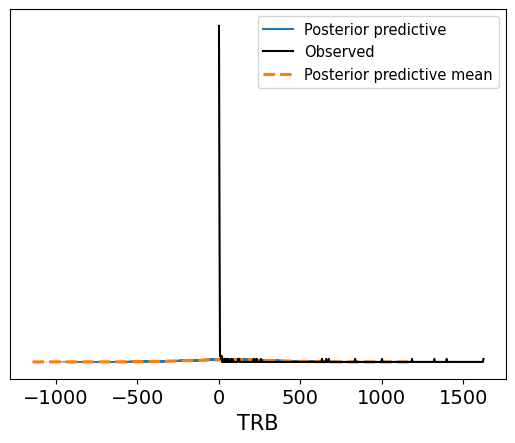

In [28]:
model_hsr_v.predict(idata_model_hsr_v, kind="response")
az.plot_ppc(idata_model_hsr_v)

In [29]:
model_hsr_hw_v_mv = bmb.Model("'TRB' ~ 'Height':'Standing Reach' + 'Height':'Wingspan' + 'Standing Vertical' + 'Vertical Leap'" , rooks, family="gaussian")
#this is bambi's equivalent Qof pm.sample()
idata_model_hsr_hw_v_mv = model_hsr_hw_v_mv.fit(idata_kwargs={"log_likelihood":True})

Output()

In [30]:
model_p_hsr = bmb.Model("'TRB' ~ 'Height':'Standing Reach'" , rooks, family="poisson")
idata_model_p_hsr = model_p_hsr.fit(idata_kwargs={"log_likelihood":True})

Output()

In [31]:
model_nb_hsr = bmb.Model("'TRB' ~ 'Height':'Standing Reach'", rooks, family="negativebinomial")
idata_model_nb_hsr = model_nb_hsr.fit(idata_kwargs={"log_likelihood":True})

Output()

In [ ]:
model_nb_hsr.predict(idata_nb_hsr, kind="response")
az.plot_ppc(idata_nb_hsr)

In [32]:
cmp_df = az.compare(
    {"height:sr + weight":idata_model_hsr_w, "height + weight + sr": idata_model_h_w_sr, "height":idata_model_h, "weight":idata_model_w, "height:sr": idata_model_hsr, "height:sr + vert": idata_model_hsr_v, "height:(sr, wingspan) + vert + mv": idata_model_hsr_hw_v_mv, "p height:sr": idata_model_p_hsr, "nb height:sr": idata_model_nb_hsr} )
cmp_df

/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
nb height:sr,0,-688.448121,7.337156,0.000000,1.0,32.874995,0.000000,True,log
height + weight + sr,1,-1306.309806,15.435779,617.861685,0.0,36.948498,27.002364,True,log
height:sr + weight,2,-1306.370379,15.078790,617.922258,0.0,37.114097,27.011109,True,log
weight,3,-1306.430267,14.766792,617.982146,0.0,37.818915,27.304121,True,log
height,4,-1306.877821,13.236231,618.429700,0.0,36.887159,26.530452,False,log
height:sr,5,-1307.123139,13.021753,618.675018,0.0,37.055038,26.645003,True,log
"height:(sr, wingspan) + vert + mv",6,-1308.344931,16.881757,619.896809,0.0,37.149547,27.434807,True,log
height:sr + vert,7,-1309.216818,15.535674,620.768696,0.0,37.542265,27.034416,True,log
p height:sr,8,-27556.349239,684.270738,26867.901118,0.0,6401.359360,6375.955532,True,log


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:797: UserWarning: Estimat

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

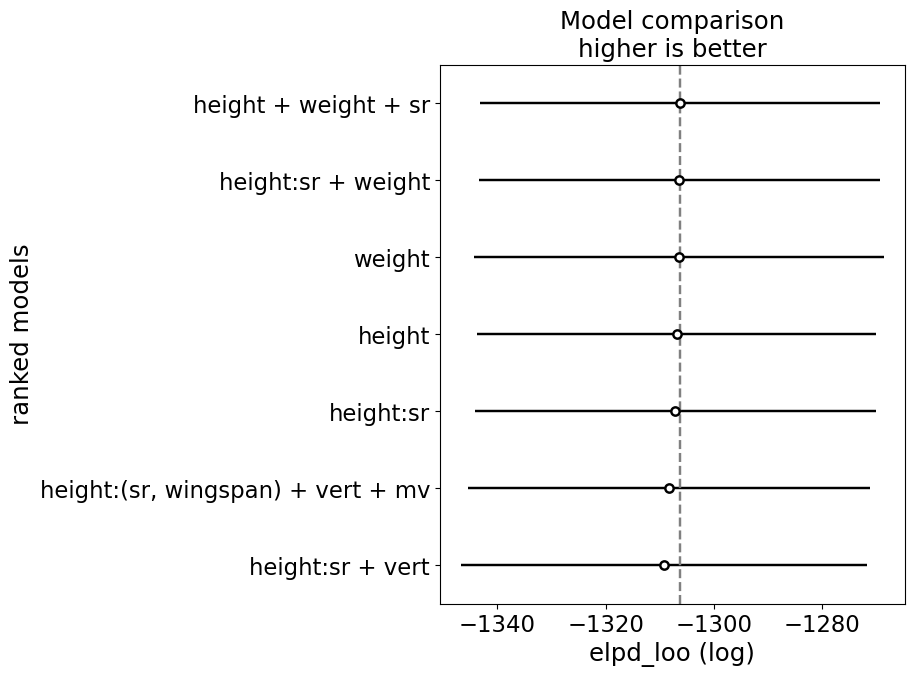

In [34]:
check = az.compare({"height:sr + weight":idata_model_hsr_w, "height + weight + sr": idata_model_h_w_sr, "height":idata_model_h, "weight":idata_model_w, "height:sr": idata_model_hsr, "height:sr + vert": idata_model_hsr_v, "height:(sr, wingspan) + vert + mv": idata_model_hsr_hw_v_mv})
az.plot_compare(check)